<a href="https://www.kaggle.com/code/kaushikfreddyregalla/01-setup-exploratory-data-analysis?scriptVersionId=325214980" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 01 — Setup & Exploratory Data Analysis
Hand Gesture Recognition | Kaushik Reddy Ragalla

In [1]:
import os, random, sys, io, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import Counter
_stderr = sys.stderr; sys.stderr = io.StringIO()
import tensorflow as tf
sys.stderr = _stderr
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.makedirs('figures', exist_ok=True)
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')


E0000 00:00:1780848836.512625      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780848836.633440      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780848837.665246      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780848837.665287      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780848837.665290      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780848837.665293      22 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow : 2.19.0
GPU        : True


In [2]:
from pathlib import Path

# Auto-find the dataset root by searching all possible base locations
SEARCH_BASES = [
    '/kaggle/input',
    '/kaggle/input/datasets',
    '/kaggle/input/datasets/kaushikfreddyregalla',
    '/kaggle/input/datasets/kaushikfreddyregalla/hand-gesture-recognition-algorithm-using-cnn',
]

DATASET_ROOT = None
for base in SEARCH_BASES:
    b = Path(base)
    if not b.exists(): continue
    for p in b.rglob('leapGestRecog'):
        if not p.is_dir(): continue
        children = [c.name for c in p.iterdir() if c.is_dir()]
        if any(c in ['00','01','02','03','04'] for c in children):
            DATASET_ROOT = p
            break
    if DATASET_ROOT: break

if DATASET_ROOT is None:
    # Last resort: walk everything and print
    print('Still not found. Full tree:')
    for r, dirs, files in os.walk('/kaggle/input'):
        print(r)
        if r.count('/') > 8: break
else:
    print(f'DATASET_ROOT = {DATASET_ROOT}')
    print(f'Subject folders: {sorted([d.name for d in DATASET_ROOT.iterdir() if d.is_dir()])}')

IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
CLASS_NAMES = [
    '01_palm', '02_l', '03_fist', '04_fist_moved',
    '05_thumb', '06_index', '07_ok',
    '08_palm_moved', '09_c', '10_down'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')


DATASET_ROOT = /kaggle/input/datasets/kaushikfreddyregalla/hand-gesture-recognition-algorithm-using-cnn/leapGestRecog
Subject folders: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
Classes (10): ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [3]:
# Collect all image paths and labels
# Structure: leapGestRecog/<subject_00-09>/<gesture_class>/<images>
all_paths, all_labels = [], []

for subject_dir in sorted(DATASET_ROOT.iterdir()):
    if not subject_dir.is_dir(): continue
    for class_dir in sorted(subject_dir.iterdir()):
        if not class_dir.is_dir(): continue
        if class_dir.name not in CLASS_NAMES: continue
        label = CLASS_NAMES.index(class_dir.name)
        for img_file in class_dir.glob('*.png'):
            all_paths.append(str(img_file))
            all_labels.append(label)

print(f'Total images       : {len(all_paths)}')
print(f'Label distribution : {Counter(all_labels)}')


Total images       : 20000
Label distribution : Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000})


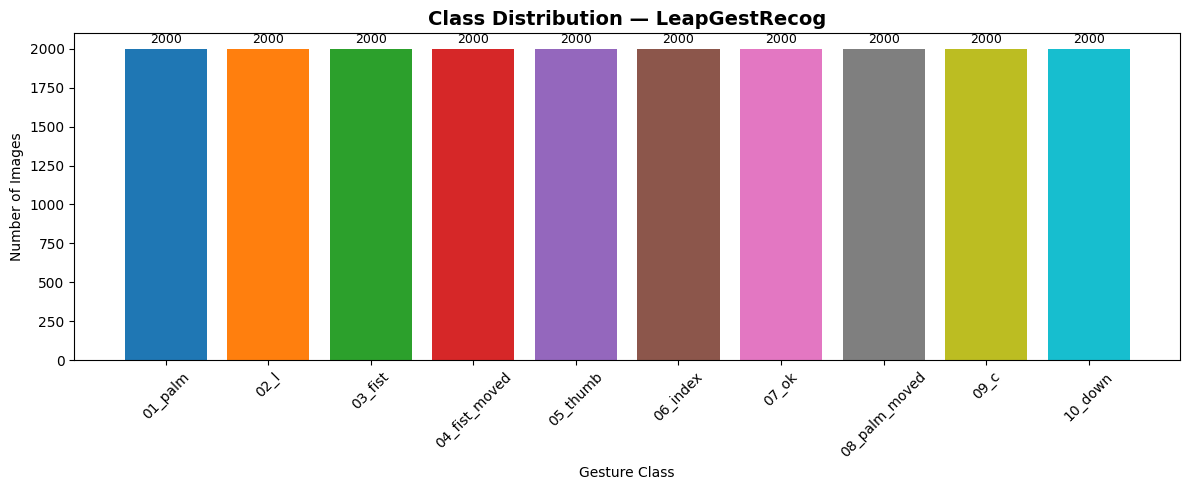

Saved: figures/class_distribution.png


In [4]:
# Class Distribution Bar Chart
label_counts = Counter(all_labels)
counts = [label_counts[i] for i in range(NUM_CLASSES)]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10.colors)
ax.set_xlabel('Gesture Class'); ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution — LeapGestRecog', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(c), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150)
plt.show()
print('Saved: figures/class_distribution.png')


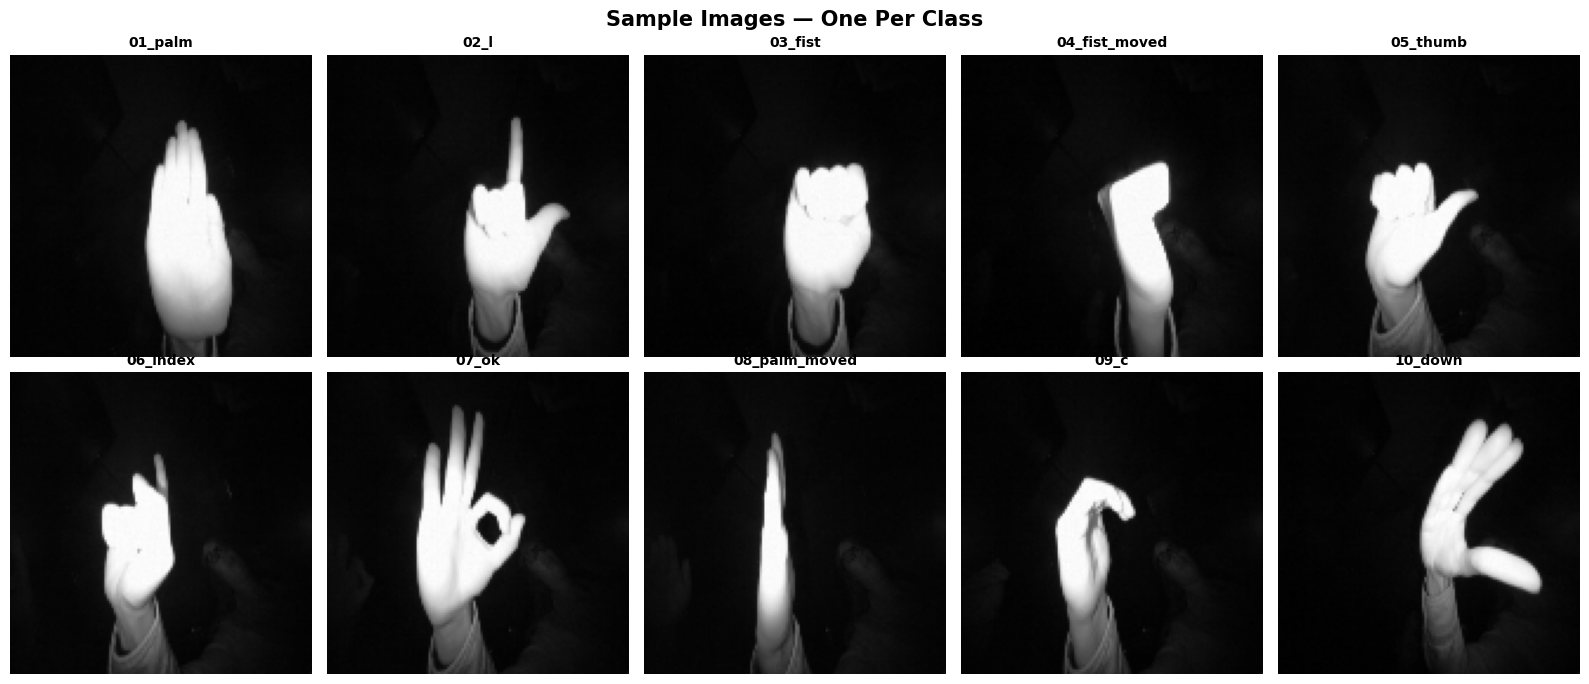

EDA complete. Figures saved to figures/


In [5]:
# Sample Images Grid — one per class
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Images — One Per Class', fontsize=15, fontweight='bold')
for idx, class_name in enumerate(CLASS_NAMES):
    class_indices = [i for i, l in enumerate(all_labels) if l == idx]
    img = cv2.imread(all_paths[class_indices[0]], cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    row, col = divmod(idx, 5)
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(class_name, fontsize=10, fontweight='bold')
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('figures/sample_images.png', dpi=150)
plt.show()
print('EDA complete. Figures saved to figures/')
